## Example 3b:
Forwards-model-only exploration of information content as a function of defocus.

Maximum total information appears to occur when `z = +/- depth_of_focus`, although it's still very much unconfirmed.

If you came here looking for ML, prepare for disappointment. If, however, you came looking for pretty graphs, well you'll still probably be a little disappointed, but I think the results are cool nevertheless. And let's face it, if you're here reading example 3b on some guy's computational physics hobby repo, you're probably a bit of a nerd too.

In [1]:
import numpy as np
import torch
from matplotlib import pyplot

In [2]:
from cynosure.config_defaults import (
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
)
from cynosure.information.fisher_information import (
    augmented_prior_covariance,
    calculate_augmented_fisher_matrix,
    calculate_mutual_information,
)
from cynosure.object_distribution import FixedBead, ObjectDistribution
from cynosure.zstack_decoding.stack_simulator import StackSimulator

#### Simulation setup
Instantiate a model so we can use its machinery, even though we won't be fitting it.

In [3]:
rng_seed = 123
z_jitter = 1.5  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config(
    min_photons=10_000,
    max_photons=10_000,
    max_background=0,
)

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)

In [5]:
# no decoder here: this notebook only needs a forward model and a prior, never a trained network
simulator = StackSimulator.from_configs(
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    noise_cfg=noise_cfg,
).to(device)

#### Analysis (i.e., the good stuff)

In [6]:
batch_size = 32
z_max = 1.5
num_z = 19

z = torch.linspace(-z_max, z_max, num_z).to(device)
phase_coefs, amp_coefs = simulator.sample_coefficients(batch_size)

Augment the Fisher matrix with an extra row+column for z, so the Z_{2n}^{0} aberrations can be separated from the defocus. As in example 3a, this will take some time.

In [7]:
fisher_samples = []
coefs = simulator.coefficients.gather_nonpinned(simulator.coefficients.join(phase_coefs, amp_coefs))  # [B, C_kept]
for coefs_i in coefs:  # TODO - figure out a way to vectorize this later
    _, augmented_fisher = calculate_augmented_fisher_matrix(coefs_i, z, simulator)
    fisher_samples.append(augmented_fisher.numpy(force=True))

num_coefs = simulator.coefficients.num_nonpinned_coefs
augmented_fisher_samples = np.stack(fisher_samples)  # [B, Z, C_kept+1, C_kept+1]
augmented_fisher_matrix = augmented_fisher_samples.mean(0)  # [Z, C_kept+1, C_kept+1]

In [8]:
prior_covariance = augmented_prior_covariance(simulator)  # [C_kept+1, C_kept+1]
prior_sigmas = np.sqrt(np.diagonal(prior_covariance))

Calculate the information content per z-plane separately for the aberration part and the defocus part. Also calculate the total, which is expected to be more than the sum of the aberration and defocus parts, since there's enough overlap between them that having both parts simultaneously meaningfully disambiguates.

In [9]:
aberration_indices = np.arange(num_coefs)
aberration_information = calculate_mutual_information(augmented_fisher_samples, prior_covariance, aberration_indices).mean(0)  # [Z,]

z_index = np.array([num_coefs])
z_information = calculate_mutual_information(augmented_fisher_samples, prior_covariance, z_index).mean(0)  # [Z,]

information = calculate_mutual_information(augmented_fisher_samples, prior_covariance).mean(0)  # [Z,]

In [10]:
def calculate_depth_of_field(opt_cfg: 'OpticalConfig') -> float:
    """Standard depth of field calculation in the high-NA regime (ignoring the geometrical term)"""
    dof = opt_cfg.wavelength * opt_cfg.immersion_index / opt_cfg.numerical_aperture**2
    return dof

In [11]:
dof = calculate_depth_of_field(opt_cfg)

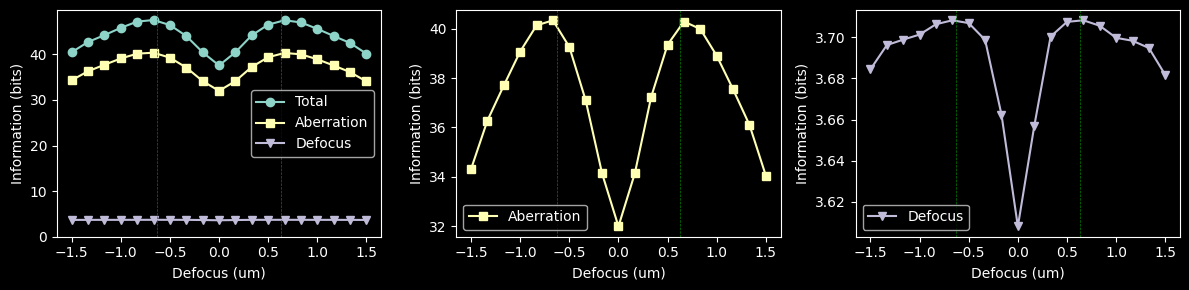

In [12]:
fig, axarr = pyplot.subplots(1, 3, figsize=(12, 3))
ax1, ax2, ax3 = axarr

ax1.plot(z.numpy(force=True), information, "o-", label="Total")
ln2, = ax1.plot(z.numpy(force=True), aberration_information, "s-", label="Aberration")
ln3, = ax1.plot(z.numpy(force=True), z_information, "v-", label="Defocus")

ax2.plot(z.numpy(force=True), aberration_information, "s-", label="Aberration", color=ln2.get_c())
ax3.plot(z.numpy(force=True), z_information, "v-", label="Defocus", color=ln3.get_c())

ax1.set_ylim(bottom=0)

for ax in axarr:
    ax.axvline(-dof, color="g", ls="--", lw=0.5)
    ax.axvline(dof, color="g", ls="--", lw=0.5)
    ax.legend()
    ax.set_xlabel("Defocus (um)")
    ax.set_ylabel("Information (bits)")
fig.tight_layout()

Per example 3a, each aberration term is easiest to measure at a different defocus. The total information, however, does have an optimal defocus (well, two, but they're symmetric), which looks to be roughly one depth-of-field away from the focal plane. Note, the depth of field actually defines a region spanning `z = [-dof/2, +dof/2]`, so the apparent maximum-information point is actually near the edge of a region spanning two depths-of-field.

Seems like quite a coincidence that the max-information point coincides roughly with `z = dof`. Let's scan the optical parameters to see if the relationship holds.

In [13]:
def run_configuration(
        sim_cfg: 'SimulationConfig',
        opt_cfg: 'OpticalConfig',
        phase_cfg: 'ZernikeConfig',
        amp_cfg: 'ZernikeConfig',
        noise_cfg: 'NoiseConfig',
        phase_prior: 'PriorConfig',
        amp_prior: 'PriorConfig',
        object_distrib: ObjectDistribution,
        num_z: int,
        batch_size: int,
        device: str | torch.device,
) -> tuple[np.ndarray, np.ndarray, float]:
    """
    Convenience function that creates a simulator, calculates the total information vs. defocus,
    and returns it along with the z-array and the estimated depth of field.
    """
    dof = calculate_depth_of_field(opt_cfg)
    z_max = 2 * dof
    z = torch.linspace(0, z_max, num_z).to(device)
    simulator = StackSimulator.from_configs(
        sim_cfg=sim_cfg,
        optics_cfg=opt_cfg,
        phase_cfg=phase_cfg,
        amp_cfg=amp_cfg,
        phase_prior_cfg=phase_prior,
        amp_prior_cfg=amp_prior,
        object_distribution=object_distrib,
        z_objective=torch.zeros(1),
        z_jitter=z_max,
        noise_cfg=noise_cfg,
    ).to(device)

    phase_coefs, amp_coefs = simulator.sample_coefficients(batch_size)

    fisher_samples = []
    coefs = simulator.coefficients.gather_nonpinned(simulator.coefficients.join(phase_coefs, amp_coefs))  # [B, C_kept]
    for coefs_i in coefs:  # TODO - figure out a way to vectorize this later
        _, augmented_fisher = calculate_augmented_fisher_matrix(coefs_i, z, simulator)
        fisher_samples.append(augmented_fisher.numpy(force=True))

    augmented_fisher_samples = np.stack(fisher_samples)  # [B, Z, C_kept+1, C_kept+1]
    prior_covariance = augmented_prior_covariance(simulator)  # [C_kept + 1, C_kept + 1]
    information = calculate_mutual_information(augmented_fisher_samples, prior_covariance).mean(0)  # [Z,]

    return z.numpy(force=True), information, dof

In [14]:
batch_size = 8  # smaller than before, since we'll have more configurations to crank through
num_z = 15

Calculating the max-information point while sweeping the numerical aperture:

In [15]:
results_by_na = {}
for na in [0.6, 0.7, 0.8, 0.9]:
    opt_cfg = get_default_optical_config(numerical_aperture=na)
    z, info, dof = run_configuration(
        sim_cfg, opt_cfg,
        phase_cfg, amp_cfg,
        noise_cfg, phase_prior, amp_prior,
        object_distrib, num_z, batch_size, device,
    )
    results_by_na[na] = (z, info, dof)

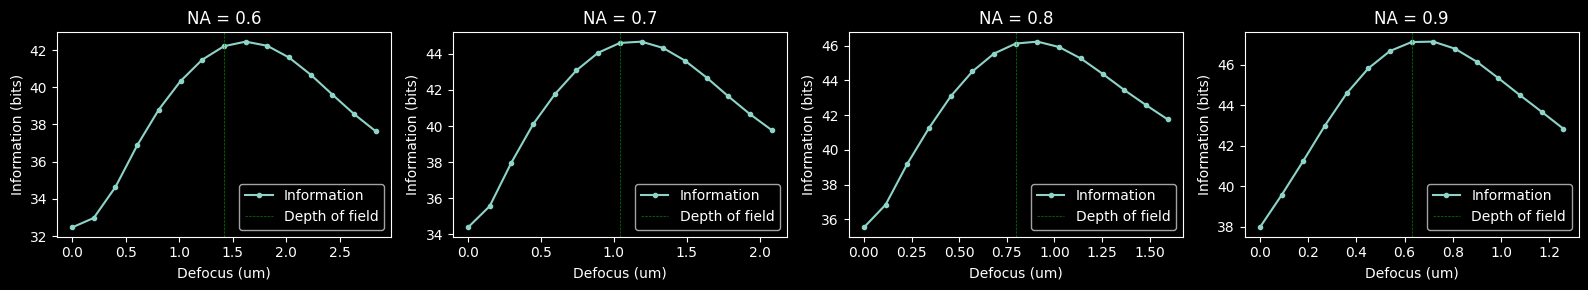

In [16]:
num_results = len(results_by_na)
fig, axarr = pyplot.subplots(1, num_results, figsize=(4*num_results, 3))
for (na, (z, info, dof)), ax in zip(results_by_na.items(), axarr):
    ax.plot(z, info, ".-", label="Information")
    ax.axvline(dof, label="Depth of field", color="g", ls="--", lw=0.5)
    ax.set_title(f"NA = {na:.1f}")
    ax.set_xlabel("Defocus (um)")
    ax.set_ylabel("Information (bits)")
    ax.legend(loc="lower right")
fig.tight_layout()

Calculating the max-information point while sweeping the wavelength:

In [17]:
results_by_wl = {}
for wl in [0.3, 0.5, 0.7, 0.9]:
    opt_cfg = get_default_optical_config(wavelength=wl)
    z, info, dof = run_configuration(
        sim_cfg, opt_cfg,
        phase_cfg, amp_cfg,
        noise_cfg, phase_prior, amp_prior,
        object_distrib, num_z, batch_size, device,
    )
    results_by_wl[wl] = (z, info, dof)

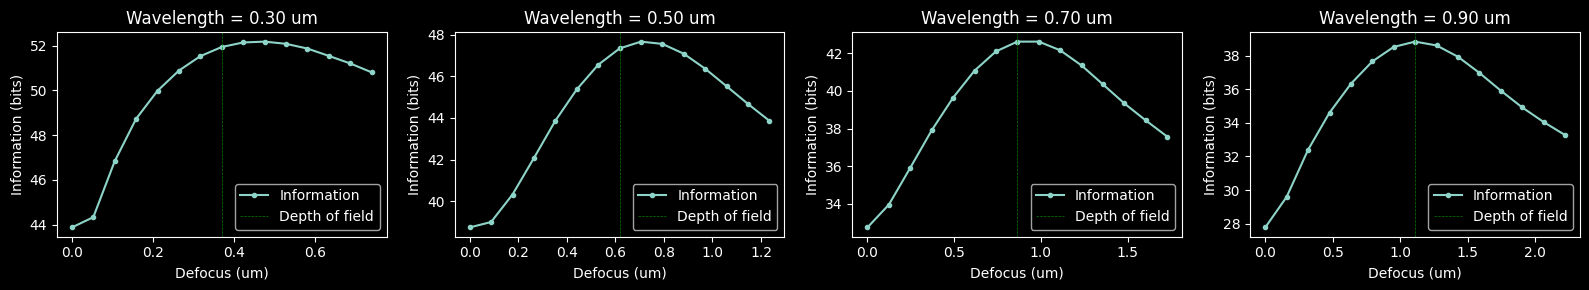

In [18]:
num_results = len(results_by_wl)
fig, axarr = pyplot.subplots(1, num_results, figsize=(4*num_results, 3))
for (wl, (z, info, dof)), ax in zip(results_by_wl.items(), axarr):
    ax.plot(z, info, ".-", label="Information")
    ax.axvline(dof, label="Depth of field", color="g", ls="--", lw=0.5)
    ax.set_title(f"Wavelength = {wl:.2f} um")
    ax.set_xlabel("Defocus (um)")
    ax.set_ylabel("Information (bits)")
    ax.legend(loc="lower right")
fig.tight_layout()

That's kind of fun. The peak of the information curve seems to roughly track with the depth of focus (note the changing x-axis of the plots). I wonder if there's something more fundamental responsible for this? Some discrepancies exist, especially at the short-wavelength end, which may be because the wavelength is getting too small compared to the object grid or the object itself.